Importing the Dependencies

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle

Data Collection and Processing

In [2]:
# load the dataset to a pandas dataframe
data = pd.read_csv('/content/Rainfall.csv')

In [3]:
# number of rows and columns
data.shape

(366, 12)

In [4]:
# first 5 records in the dataset
data.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [5]:
# last 5 records in the dataset
data.tail()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
361,27,1022.7,18.8,17.7,16.9,15.0,84,90,yes,0.0,30.0,18.4
362,28,1026.6,18.6,17.3,16.3,12.8,75,85,yes,1.0,20.0,25.9
363,29,1025.9,18.9,17.7,16.4,13.3,75,78,yes,4.6,70.0,33.4
364,30,1025.3,19.2,17.3,15.2,13.3,78,86,yes,1.2,20.0,20.9
365,31,1026.4,20.5,17.8,15.5,13.0,74,66,no,5.7,20.0,23.3


In [6]:
data.day.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [7]:
# showing info about the data/columns
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [10]:
# removing spaces in the column names
data.columns = data.columns.str.strip()

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   day            366 non-null    int64  
 1   pressure       366 non-null    float64
 2   maxtemp        366 non-null    float64
 3   temparature    366 non-null    float64
 4   mintemp        366 non-null    float64
 5   dewpoint       366 non-null    float64
 6   humidity       366 non-null    int64  
 7   cloud          366 non-null    int64  
 8   rainfall       366 non-null    object 
 9   sunshine       366 non-null    float64
 10  winddirection  365 non-null    float64
 11  windspeed      365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [12]:
data.drop('day', axis=1, inplace=True)

In [13]:
# checking the number of missing values
data.isna().sum()

,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0
winddirection,1


In [14]:
data.winddirection.unique()

array([ 80.,  50.,  40.,  20.,  30.,  60.,  70.,  10., 200., 220., 120.,
       190., 210., 300., 240., 180., 230.,  90., 170., 150., 100., 130.,
        nan, 160., 270., 280., 250., 260., 290., 350., 110., 140.])

In [15]:
data.windspeed.unique()

array([26.3, 15.3, 14.2, 16.9, 13.7, 14.5, 21.5, 14.3, 39.3, 37.7, 23.3,
       23.9, 24.4, 33.2, 37.5, 40. , 23.4, 28.4, 38. , 50.6, 26.2, 35.3,
       55.5, 59.5, 28.7, 21.3, 29.6, 28.8, 25. , 21.2, 43.1, 31.9, 27.3,
        9.1, 44.7, 20.5, 16.7, 17.2, 22. , 15.8, 13.9, 10.2, 33.5, 23.5,
       19.2, 18.6, 22.2, 19.3, 28. , 20.4, 15.2,  9.2, 34.2, 27.1, 14.7,
       15.4, 13.3,  6.6, 13.8, 15.1, 39.7, 36. , 22.8, 26.7, 26.5, 13.1,
       12.5, 38.3, 42. , 19.4, 13.4, 14.6, 26.9, 14.8,  4.5,  8.3,  8. ,
       20. , 10. , 17.3, 31.8, 29.8, 11.2, 16. , 19.6, 20.9,  7.3, 11.1,
       13. ,  8.5, 24.2, 20.2, 30.5, 27. , 23.7, 11.8, 15.5, 12.1,  9.5,
       16.3, 12. , 26. , 28.6, 24.9, 28.3, 15.7, 21.9, 39.5, 30.3, 26.4,
       22.3, 25.9, 11.3,  7.9,  7.4, 16.2, 34.8, 32.5, 24. , 19. , 25.2,
       31.7, 27.4, 20.8,  9.8, 12.6,  nan, 24.3, 30. , 29.3, 23.2, 12.8,
       19.8, 12.4, 10.9,  9.6,  9. , 11.9, 26.1, 25.1, 33. , 22.5, 24.8,
       18.8, 22.4, 22.6, 12.3, 21.6, 17.5, 16.1, 14

In [16]:
# handling the missing data
data.winddirection.fillna(data.winddirection.value_counts().idxmax(), inplace=True)
data.windspeed.fillna(data.windspeed.mean(), inplace=True)

/tmp/ipykernel_2267/1497259290.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.winddirection.fillna(data.winddirection.value_counts().idxmax(), inplace=True)
/tmp/ipykernel_2267/1497259290.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col]

In [17]:
#confirming null values have been removed
data.isna().sum()

,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0
winddirection,0


In [18]:
data.rainfall.unique()

array(['yes', 'no'], dtype=object)

In [19]:
# converting the yes & no to 1 and 0 respectively
data.rainfall = data.rainfall.map({'yes':1, 'no':0})

In [20]:
data.rainfall.unique()

array([1, 0])

In [21]:
data.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,1,0.0,40.0,13.7


**Exploratory Data Analysis (EDA)**

In [22]:
# setting plot style for all the plots
sns.set(style='whitegrid')

In [23]:
data.describe()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,0.680328,4.419399,101.284153,21.536986
std,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,0.466988,3.934398,81.722827,10.055908
min,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,0.000000,10.000000,4.400000
25%,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.000000,0.500000,40.000000,13.725000
50%,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,1.000000,3.500000,70.000000,20.500000
75%,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,1.000000,8.200000,190.000000,27.825000
max,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,1.000000,12.100000,350.000000,59.500000


In [24]:
data.columns

Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed'],
      dtype='object')

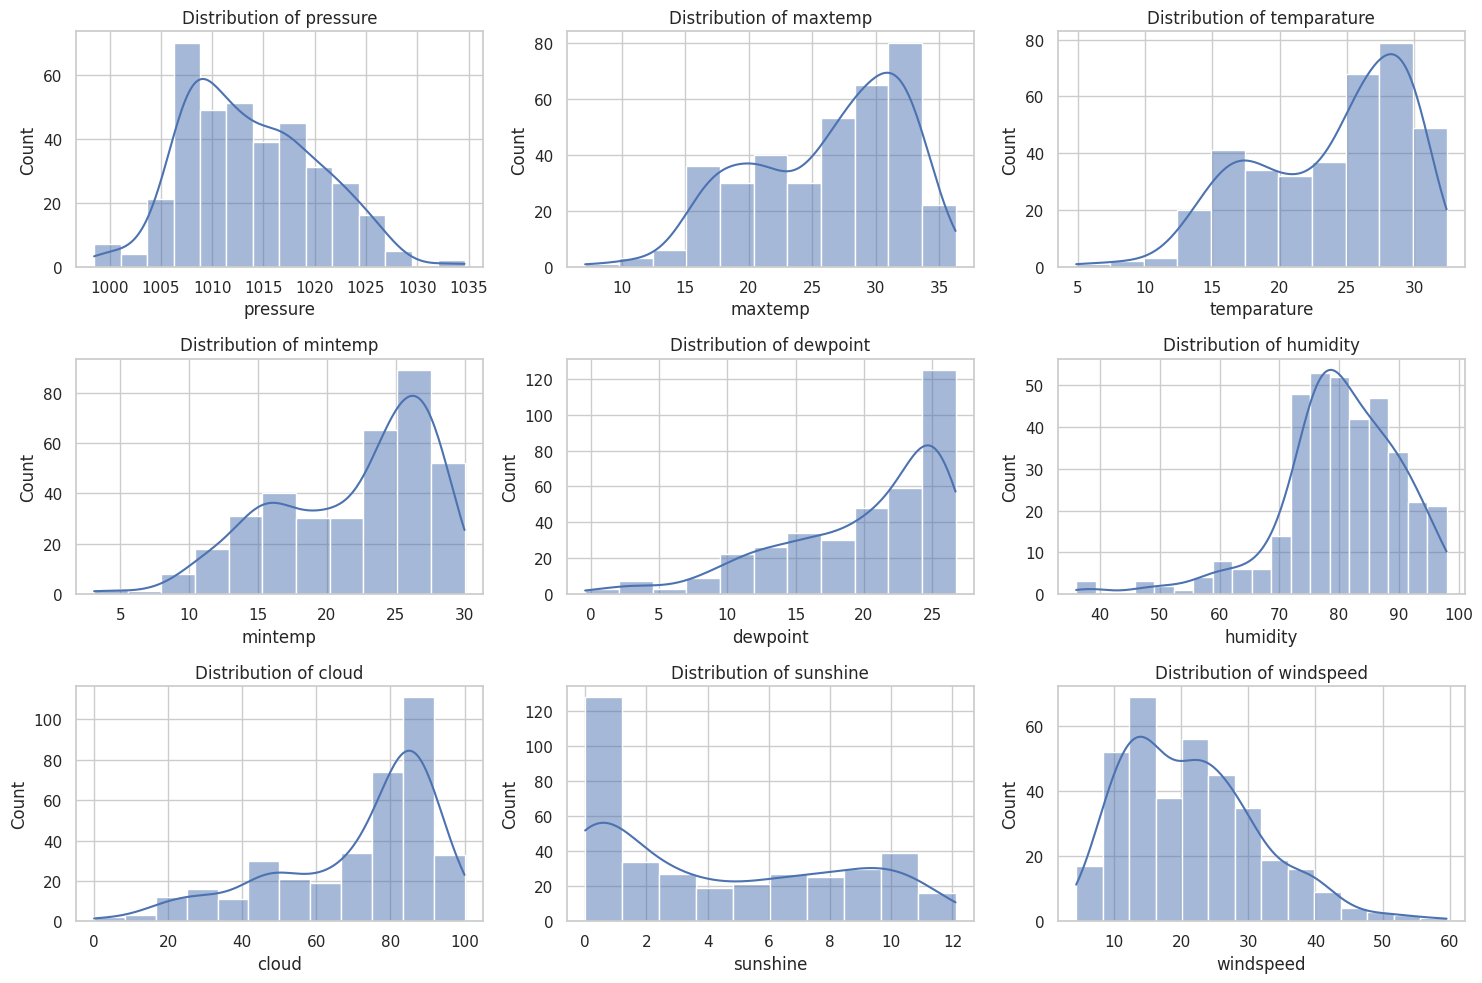

In [30]:
plt.figure(figsize=(15,10))
for i, column in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'sunshine', 'windspeed'],1):
  plt.subplot(3,3,i)
  sns.histplot(data[column], kde=True)
  plt.title(f'Distribution of {column}')
plt.tight_layout()
plt.show()

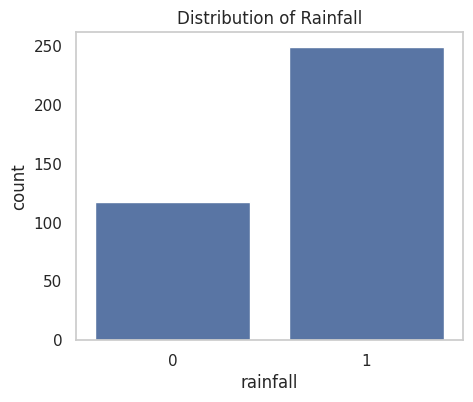

In [32]:
plt.figure(figsize=(5,4))
plt.grid(None)
sns.countplot(x='rainfall', data=data)
plt.title('Distribution of Rainfall')
plt.show()

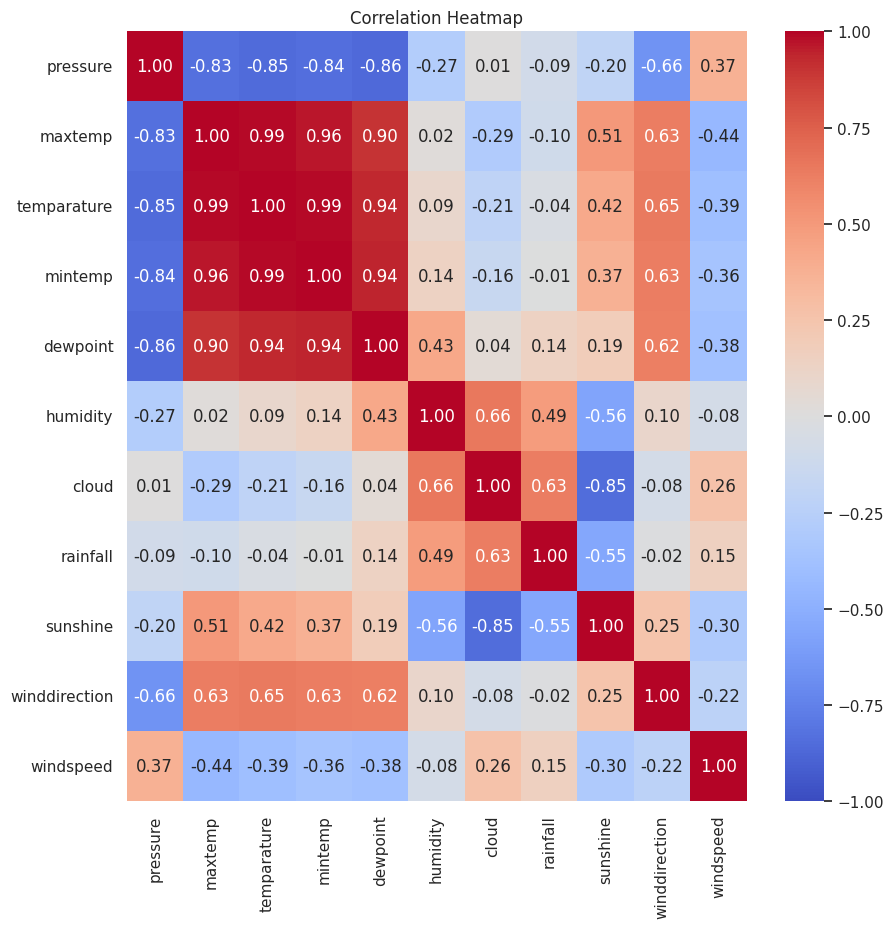

In [33]:
# correlation matrix
plt.figure(figsize=(10,10))
sns.heatmap(data.corr(), annot=True, center=0, vmin=-1, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

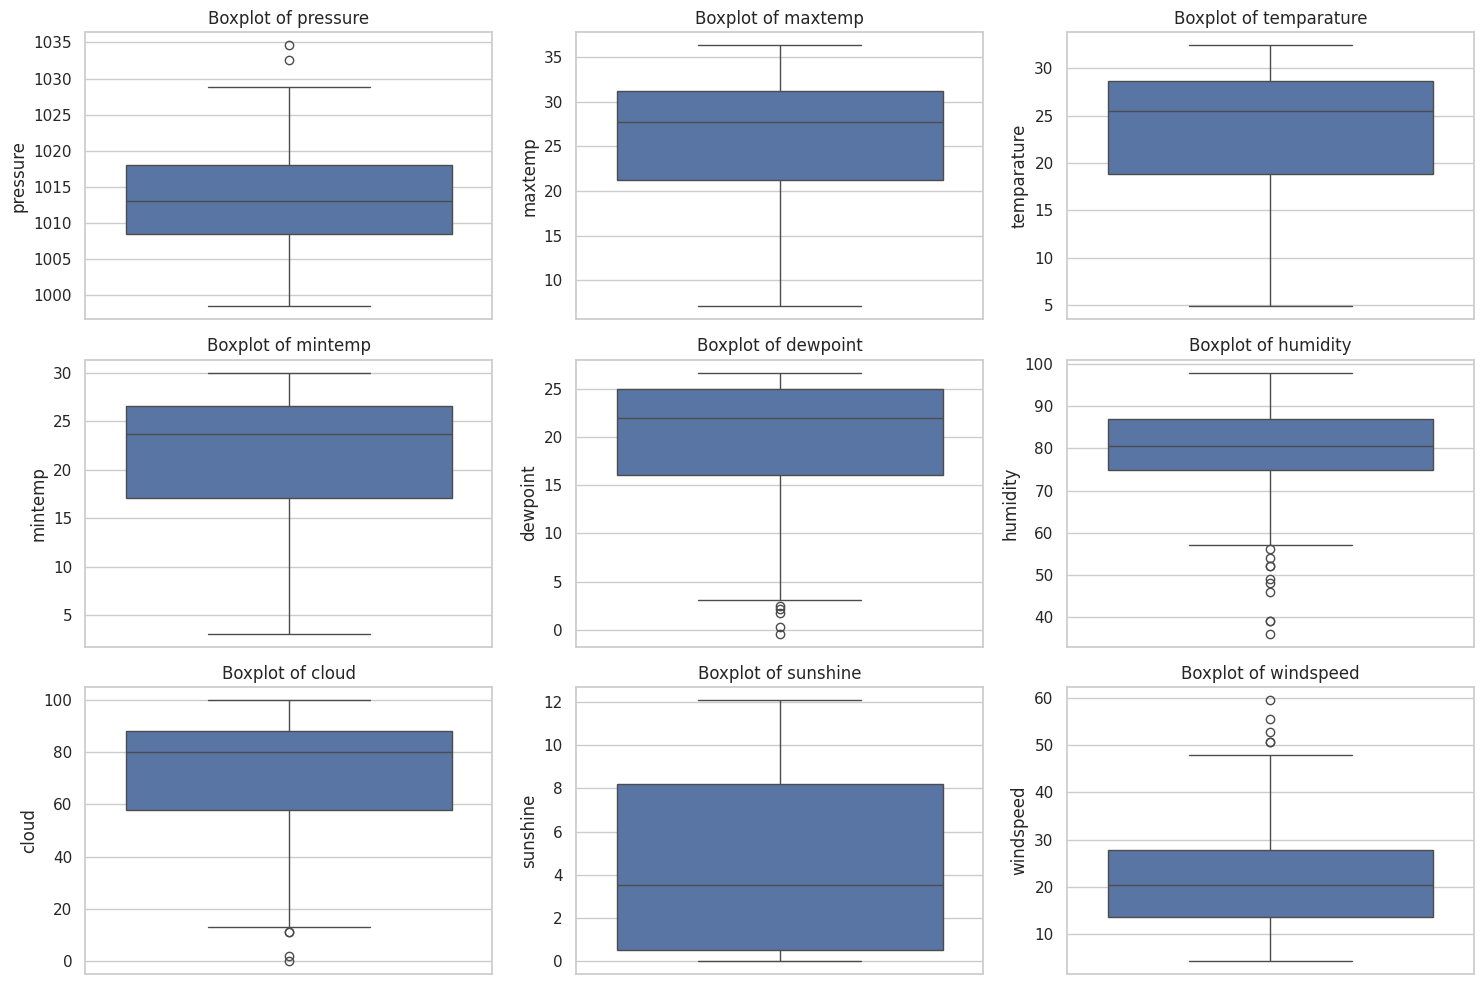

In [35]:
plt.figure(figsize=(15,10))
for i, column in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'sunshine', 'windspeed'],1):
  plt.subplot(3,3,i)
  sns.boxplot(data[column])
  plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.show()

Data Preprocessing

In [37]:
# drop highly correlated columns
data.drop(['mintemp','maxtemp','temparature'],axis=1, inplace=True)
data.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,19.9,95,81,1,0.0,40.0,13.7


In [38]:
data.rainfall.value_counts()

,count
rainfall,
1,249
0,117


In [39]:
# separate majority and minority class
df_majority = data[data.rainfall==1]
df_minority = data[data.rainfall==0]


In [40]:
# downsample majority class to match minority class
df_majority_downsampled = resample(df_majority, replace=False, n_samples=len(df_minority), random_state=1)


In [41]:
df_majority_downsampled.shape

(117, 8)

In [42]:
df_downsampled = pd.concat([df_majority_downsampled, df_minority])

In [43]:
df_downsampled.shape

(234, 8)

In [44]:
df_downsampled.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
101,1010.1,19.9,91,89,1,0.0,70.0,31.8
364,1025.3,13.3,78,86,1,1.2,20.0,20.9
309,1016.1,22.0,80,82,1,6.5,70.0,28.3
228,1008.5,26.5,86,88,1,0.2,230.0,18.0
130,1008.1,24.3,87,84,1,0.3,220.0,12.0


In [45]:
df_downsampled = df_downsampled.sample(frac=1, random_state=1).reset_index(drop=True)

In [46]:
df_downsampled.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1004.9,25.3,78,38,0,11.0,230.0,20.5
1,1005.5,21.6,98,93,1,0.0,40.0,14.5
2,1026.4,13.0,74,66,0,5.7,20.0,23.3
3,1025.9,13.3,75,78,1,4.6,70.0,33.4
4,1023.8,11.4,72,32,0,10.6,60.0,27.1


In [47]:
# splitting features and target as X and y
X = df_downsampled.drop('rainfall', axis=1)
y = df_downsampled.rainfall

In [48]:
# splitting the data into training data and test data
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=.2, random_state=1)

Model Training

In [50]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=1)

param_grid_rf = {
    'n_estimators':[50, 100, 200],
    'max_features':['sqrt','log2'],
    'max_depth':[None, 10, 20, 30],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
    }


In [51]:
# Hypertuning using GridSearchCV
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=5,n_jobs=-1, verbose=2)
grid_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=1), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [52]:
best_rf_model = grid_search_rf.best_estimator_

print('best parameters for Random Forest', grid_search_rf.best_params_)

best parameters for Random Forest {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}


Model Evaluation

In [53]:
cv_scores = cross_val_score(best_rf_model, X_train, y_train, cv=5)
print('Cross Validation Scores', cv_scores)
print('Mean of Cross-Validation Scores', np.mean(cv_scores))

Cross Validation Scores [0.84210526 0.73684211 0.78378378 0.75675676 0.78378378]
Mean of Cross-Validation Scores 0.7806543385490754


In [55]:
# test set performance
ypred = best_rf_model.predict(X_test)

print('Test set Accuracy',accuracy_score(ypred,y_test))
print('Test set Confusion Matrix',confusion_matrix(ypred, y_test))
print('Classification Report',classification_report(ypred, y_test))


Test set Accuracy 0.6595744680851063
Test set Confusion Matrix [[13  8]
 [ 8 18]]
Classification Report               precision    recall  f1-score   support

           0       0.62      0.62      0.62        21
           1       0.69      0.69      0.69        26

    accuracy                           0.66        47
   macro avg       0.66      0.66      0.66        47
weighted avg       0.66      0.66      0.66        47



In [60]:
np.array(df_downsampled.iloc[0])

array([1004.9,   25.3,   78. ,   38. ,    0. ,   11. ,  230. ,   20.5])

In [65]:
int(best_rf_model.predict([np.array(X.iloc[0])]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/tmp/ipykernel_2267/2688408074.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  int(best_rf_model.predict([np.array(X.iloc[0])]))


0